# GIAI ĐOẠN 0: LẤY MẪU (SMART SAMPLING)

### 1. Lấy mẫu theo người dùng (user-based).
### 2. Xác định ngưỡng lọc (Threshold).


--- KẾT QUẢ TRINH SÁT DỮ LIỆU ---
Tổng số học sinh duy nhất: 19532
🏆 Số lượng câu hỏi nhiều nhất được làm: 15871 câu
📊 Trung bình mỗi học sinh làm: 256.0 câu
📍 Mức trung vị (Median): 40.0 câu


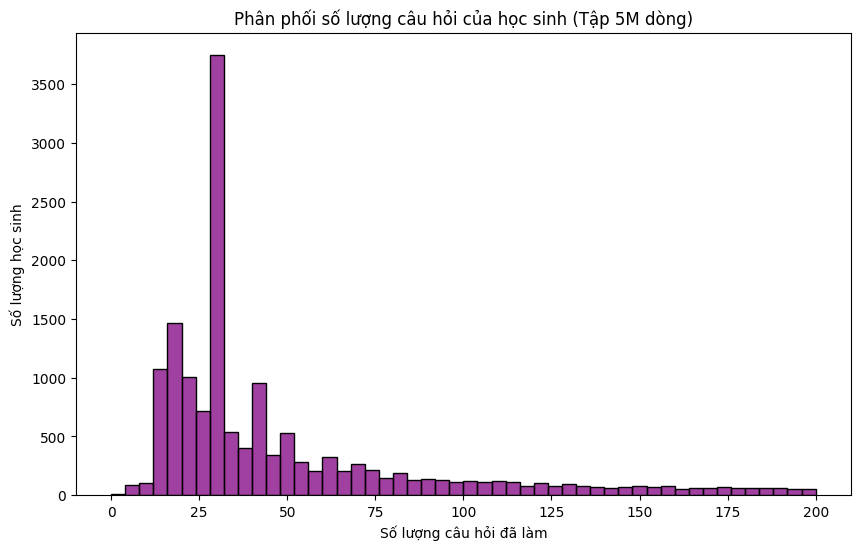

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_goc = r"D:\Question_Difficulty_and_Student_Ability_Discrimination\data\train.csv" 
df_massive = pd.read_csv(file_goc, nrows=5000000)

# Đếm số lượng câu hỏi mà mỗi học sinh (user_id) đã làm
user_counts = df_massive['user_id'].value_counts()

max_questions = user_counts.max()
median_questions = user_counts.median()
mean_questions = user_counts.mean()

print("\n--- KẾT QUẢ TRINH SÁT DỮ LIỆU ---")
print(f"Tổng số học sinh duy nhất: {len(user_counts)}")
print(f"🏆 Số lượng câu hỏi nhiều nhất được làm: {max_questions} câu")
print(f"📊 Trung bình mỗi học sinh làm: {mean_questions:.1f} câu")
print(f"📍 Mức trung vị (Median): {median_questions} câu")

plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=50, binrange=(0, 200), color='purple')

plt.title('Phân phối số lượng câu hỏi của học sinh (Tập 5M dòng)')
plt.xlabel('Số lượng câu hỏi đã làm')
plt.ylabel('Số lượng học sinh')
plt.show()

### Nhận xét phân phối dữ liệu:
- Đa số học sinh làm quanh mốc 30-40 câu (Trung vị = 40). Đỉnh tháp ở mốc 30 câu.
- Có nhiều học sinh chỉ làm 1-10 câu rồi bỏ ngang.
=> Chọn mốc **$\ge 30$ câu hỏi** để lọc ra dữ liệu nhiễu làm ảnh hưởng kết quả

In [2]:
nguong_loc = 30 

print(f"Lọc những học sinh làm từ {nguong_loc} câu trở lên")

valid_users = user_counts[user_counts >= nguong_loc].index

df_smart_sample = df_massive[df_massive['user_id'].isin(valid_users)]

# Lưu file
save_path = r"D:\Question_Difficulty_and_Student_Ability_Discrimination\data\smart_sample_train.csv"
df_smart_sample.to_csv(save_path, index=False)

print("LƯU THÀNH CÔNG.")

Lọc những học sinh làm từ 30 câu trở lên
LƯU THÀNH CÔNG.
